Found valid_scenarios_cache.json in: /home/damiano/Desktop/EdgeSimPy/adapters/cavia/valid_scenarios_cache.json
Loading scenario: CAVIA/src/LR/1_26_solution_v1



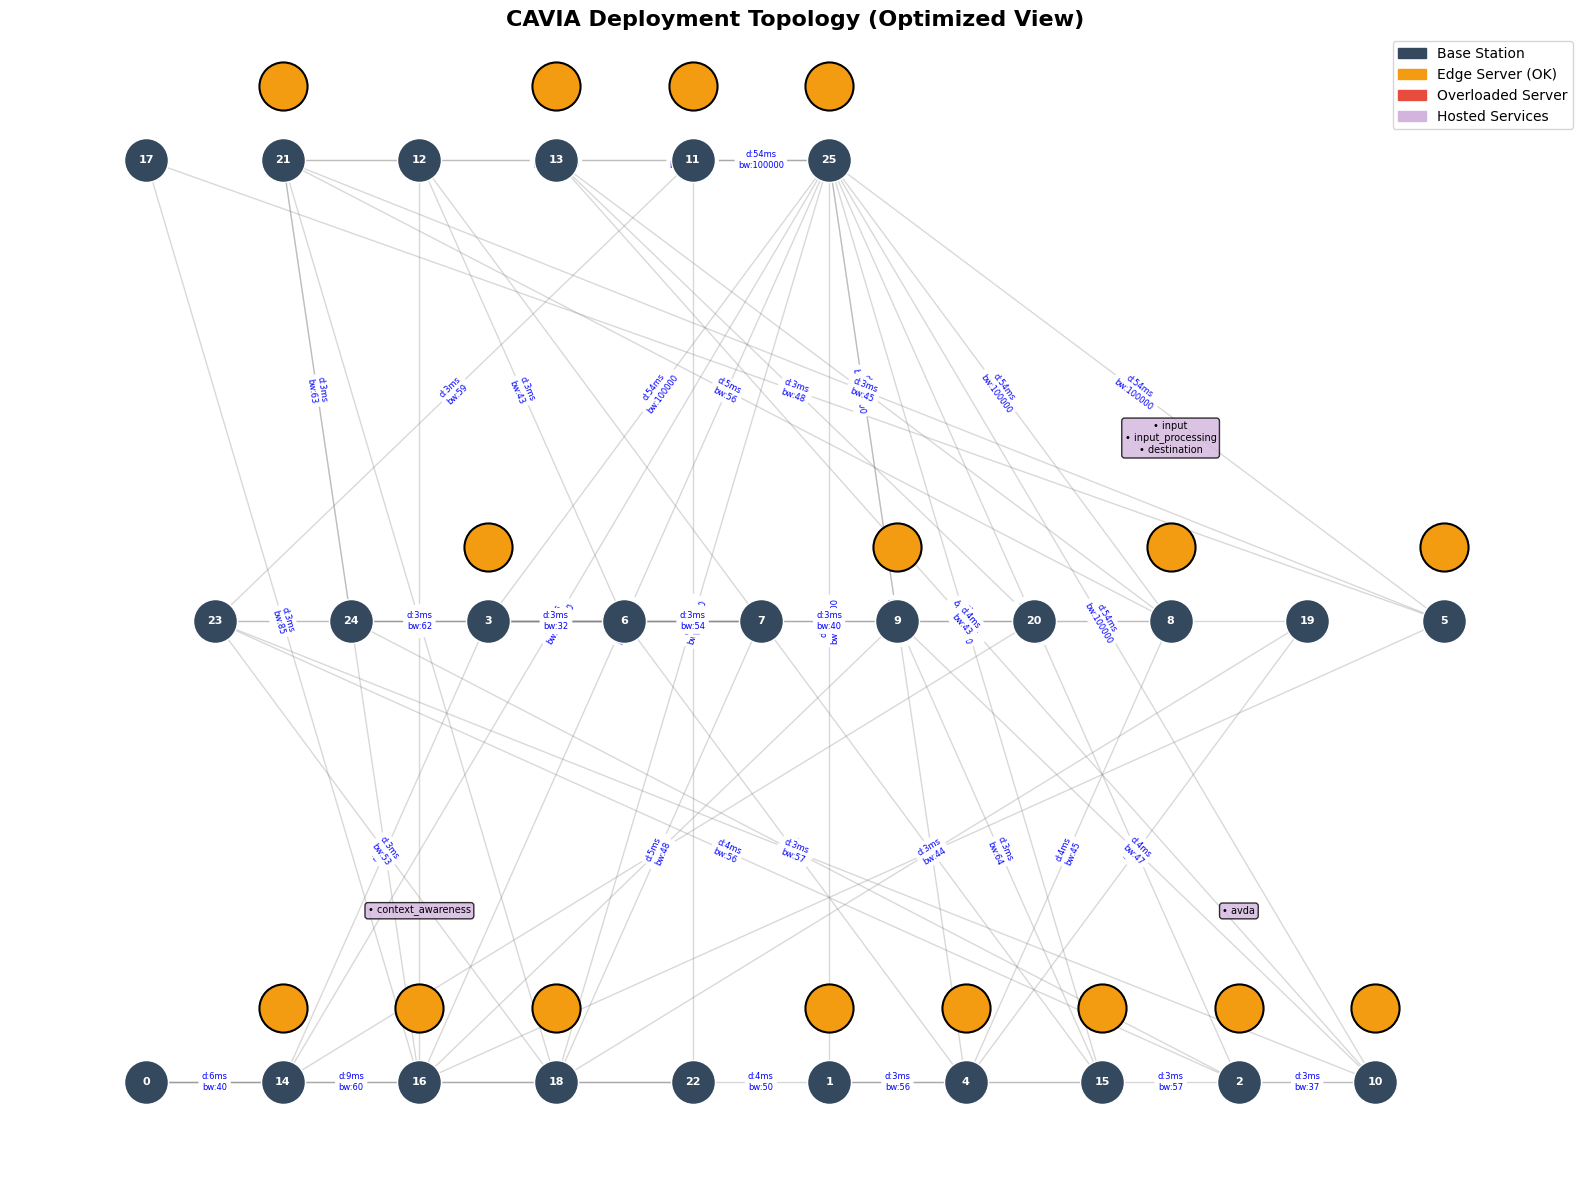

In [1]:
import pickle
import os
import networkx as nx  # type: ignore

from adapters.cavia.find_valid_scenarios import find_or_load_scenarios
from edge_sim_py.components.application import Application
from edge_sim_py.components.base_station import BaseStation
from edge_sim_py.components.edge_server import EdgeServer
from edge_sim_py.components.network_link import NetworkLink
from edge_sim_py.components.network_switch import NetworkSwitch
from edge_sim_py.components.service import Service
from edge_sim_py.components.topology import Topology
from edge_sim_py.dataset_generator.map.hexagonal_grid import hexagonal_grid
from visualization.plot_cavia_topology import plot_cavia_topology


class CaviaScenarioLoader:
    def __init__(self, physical_graph_path, app_graph_path, pkl_path):
        self.physical_graph_path = physical_graph_path
        self.app_graph_path = app_graph_path
        self.pkl_path = pkl_path

        with open(self.pkl_path, "rb") as f:
            self.data_pkl = pickle.load(f)

    def build_scenario(self):
        # Load topology, basestations, switch, server
        topology, node_server_map = self._load_topology()

        # Load Services, Application
        app, service_map = self._load_services()

        # Placement with x_ui
        self._place_services(service_map, node_server_map)

        return topology, app

    def _load_topology(self):
        G = nx.read_graphml(self.physical_graph_path)
        topology = Topology()
        node_switch_map = {}
        node_server_map = {}

        coords_list = hexagonal_grid(x_size=10, y_size=10)

        x_ui = self.data_pkl.get("x_ui", {})
        x_ui_filtered = {k: v for k, v in x_ui.items() if v > 0.5}

        nodes_used_by_solver = set()
        if x_ui_filtered:
            nodes_used_by_solver = {i for (u, i) in x_ui_filtered.keys()}

        for index, (node_id, data) in enumerate(G.nodes(data=True)):

            current_coords = coords_list[index] if index < len(coords_list) else (0, 0)

            # print(f"Processing node {node_id} with data: {data}")

            u_id = int(node_id)
            bs = BaseStation(u_id)
            switch = NetworkSwitch(u_id)

            bs.wireless_delay = 0
            bs.coordinates = current_coords
            bs._connect_to_network_switch(switch)
            node_switch_map[u_id] = switch
            topology.add_node(switch)

            cpu = int(data.get("0", 0))
            memory = int(data.get("1", 0))

            if cpu > 0 or memory > 0 or u_id in nodes_used_by_solver:

                server = EdgeServer(u_id)
                server.cpu = cpu
                server.memory = memory
                bs._connect_to_edge_server(server)
                node_server_map[u_id] = server

        for u, v, data in G.edges(data=True):
            # print(f"Processing edge {u} -> {v} with data: {data}")

            switch_u = node_switch_map[int(u)]
            switch_v = node_switch_map[int(v)]

            link = NetworkLink()
            link.topology = topology
            link.nodes = [switch_u, switch_v]
            link.delay = int(data.get("latency", 0))
            link.bandwidth = int(data.get("bandwidth", 0))

            topology.add_edge(switch_u, switch_v, object=link, delay=link.delay, bandwidth=link.bandwidth)
            switch_u.links.append(link)

        return topology, node_server_map

    def _load_services(self):
        G = nx.read_graphml(self.app_graph_path)
        service_map = {}
        app = Application()

        for node_id, data in G.nodes(data=True):
            # print(f"Processing node {node_id} with data: {data}")

            u_id = int(node_id)
            service = Service(u_id)
            service.label = data.get("node_type", f"service_{u_id}")
            service.cpu_demand = int(data.get("0", 0))
            # service.memory_demand = int(data.get("3", 0))
            # service.processing_time = int(data.get("4", 0))
            service.step = int(data.get("step", 0))
            service_map[u_id] = service

        for u, v, data in G.edges(data=True):
            # print(f"Processing edge {u} -> {v} with data: {data}")

            service_u = service_map[int(u)]
            service_u.processing_output = int(data.get("3", 0))

        for service in sorted(service_map.values(), key=lambda s: s.step):
            app.connect_to_service(service)

        return app, service_map

    def _place_services(self, service_map, node_server_map):

        x_ui = self.data_pkl.get("x_ui", {})
        x_ui_filtered = {k: v for k, v in x_ui.items() if v > 0.5}

        for (id_servizio, id_nodo), _ in x_ui_filtered.items():

            server = node_server_map.get(id_nodo)
            service = service_map.get(id_servizio)

            if server and service:

                server.services.append(service)
                service.server = server

                server.cpu_demand += service.cpu_demand
                # server.memory_demand += service.memory_demand

                service._available = True


# physical_graph_path = "scenarios/cavia/1_26_solution_v0/physical_graph.graphml"
# app_graph_path = "scenarios/cavia/1_26_solution_v0/ms/1MMM.graphml"
# pkl_path = "scenarios/cavia/1_26_solution_v0/var_coeff_values_1MMM_lrslss.pkl"


HOME_DIR = os.path.expanduser("~")
BASE_PATH = os.path.join(HOME_DIR, "Desktop")
PKL_PATH = os.path.join(BASE_PATH, "CAVIA", "src", "LR")

scenarios = find_or_load_scenarios(PKL_PATH)
scenario = scenarios[0]
print("Loading scenario:", scenario + "\n")

physical_graph_path = os.path.join(BASE_PATH, scenario, "physical_graph.graphml")
app_graph_path = os.path.join(BASE_PATH, scenario, "ms/1MMM.graphml")
pkl_path = os.path.join(BASE_PATH, scenario, "var_coeff_values_1MMM_slss.pkl")

topology, app = CaviaScenarioLoader(
    physical_graph_path=physical_graph_path,
    app_graph_path=app_graph_path,
    pkl_path=pkl_path,
).build_scenario()

plot_cavia_topology()